In [ ]:
import pickle
import json

from matplotlib import pyplot as plt
from typing import Dict, Any
from pathlib import Path

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2026-03-02 10:41:06,247 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_data = json.load(f)["performance_scores"]


# FlyWing

In [3]:
SEG_results_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/ensemble_scores/to_FlyWing/SEG_results.pkl"
with open(SEG_results_path, "rb") as f:
    SEG_results = pickle.load(f)

In [4]:
methods = SEG_results["methods"]
agree_ratios = SEG_results["agree_ratios"]
radii = SEG_results["radii"]
weights = SEG_results["weights"]
eq_f1s = SEG_results["eq_f1s"]
uneq_f1s = SEG_results["uneq_f1s"]
target = SEG_results["target"]

In [ ]:
for r in radii:
    kt_eq = []
    sp_eq = []
    pe_eq = []
    kt_uneq = []
    sp_uneq = []
    pe_uneq = []

    for agree_ratio in agree_ratios:
        print(f"Radius: {r}, Agree ratio: {agree_ratio}")
        f1s_uneq: dict[str, float] = {}
        f1s_eq: dict[str, float] = {}
        for i, m in enumerate(methods):
            f1s_uneq[m] = uneq_f1s[r][agree_ratio][i]
            f1s_eq[m] = eq_f1s[r][agree_ratio][i]
        
        performance_scores = {target: performance_data[target]}
        SEG_scores_uneq = {target: f1s_uneq}
        SEG_scores_eq = {target: f1s_eq}

        KT_scores_eq, SP_scores_eq, PE_scores_eq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_eq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
            )
        
        correlation_df_eq = correlation_table(KT_scores_eq, SP_scores_eq, PE_scores_eq, targets=[target])
        print("eq_weight")
        print(correlation_df_eq)

        KT_scores_uneq, SP_scores_uneq, PE_scores_uneq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_uneq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
        )
        correlation_df_uneq = correlation_table(KT_scores_uneq, SP_scores_uneq, PE_scores_uneq, targets=[target])
        print("uneq_weight")
        print(correlation_df_uneq)

Radius: 20, Agree ratio: 0.25
eq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.2     0.82    0.3        0.67  0.45     0.44
uneq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.2     0.74    0.2        0.77  0.31     0.61
Radius: 20, Agree ratio: 0.5
eq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.8     0.08    0.9        0.07  0.76     0.14
uneq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.4     0.48    0.4        0.49  0.66     0.23
Radius: 20, Agree ratio: 0.75
eq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mit

Radius: 18, Agree ratio: 0.25
Radius: 20, Agree ratio: 0.25
Radius: 22, Agree ratio: 0.25


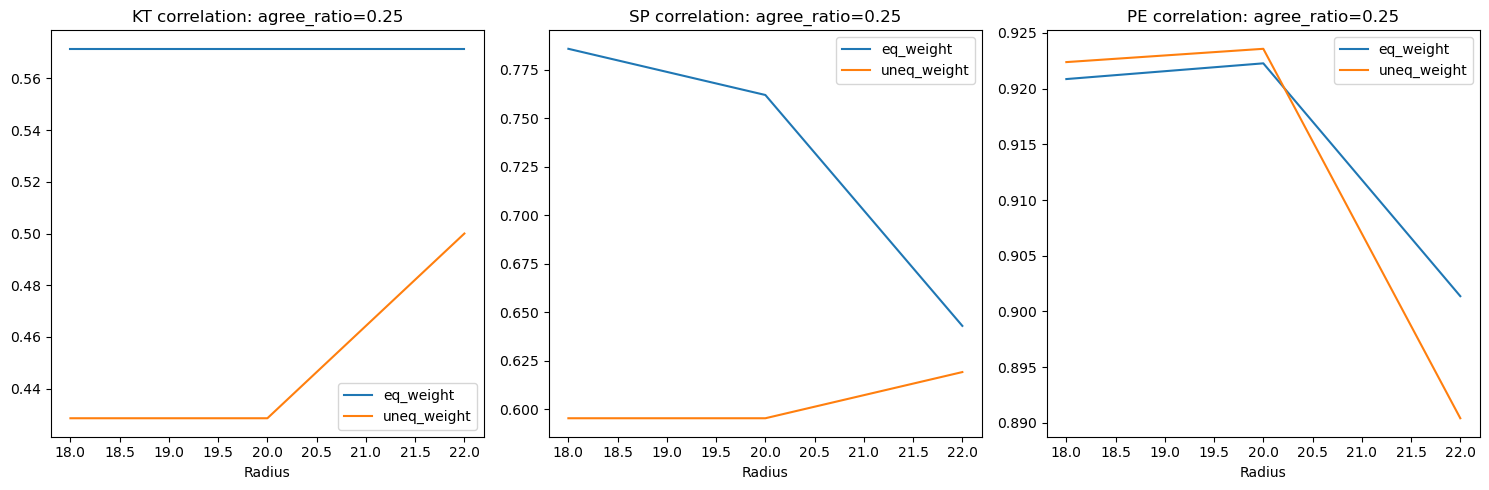

Radius: 18, Agree ratio: 0.5
Radius: 20, Agree ratio: 0.5
Radius: 22, Agree ratio: 0.5


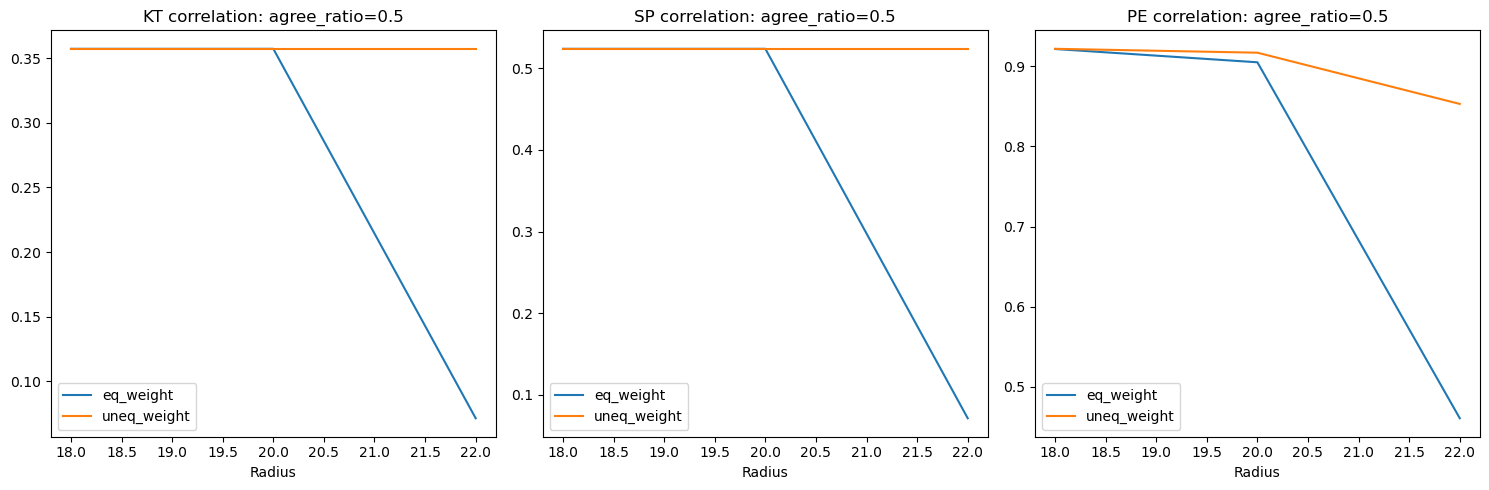

Radius: 18, Agree ratio: 0.75
Radius: 20, Agree ratio: 0.75
Radius: 22, Agree ratio: 0.75


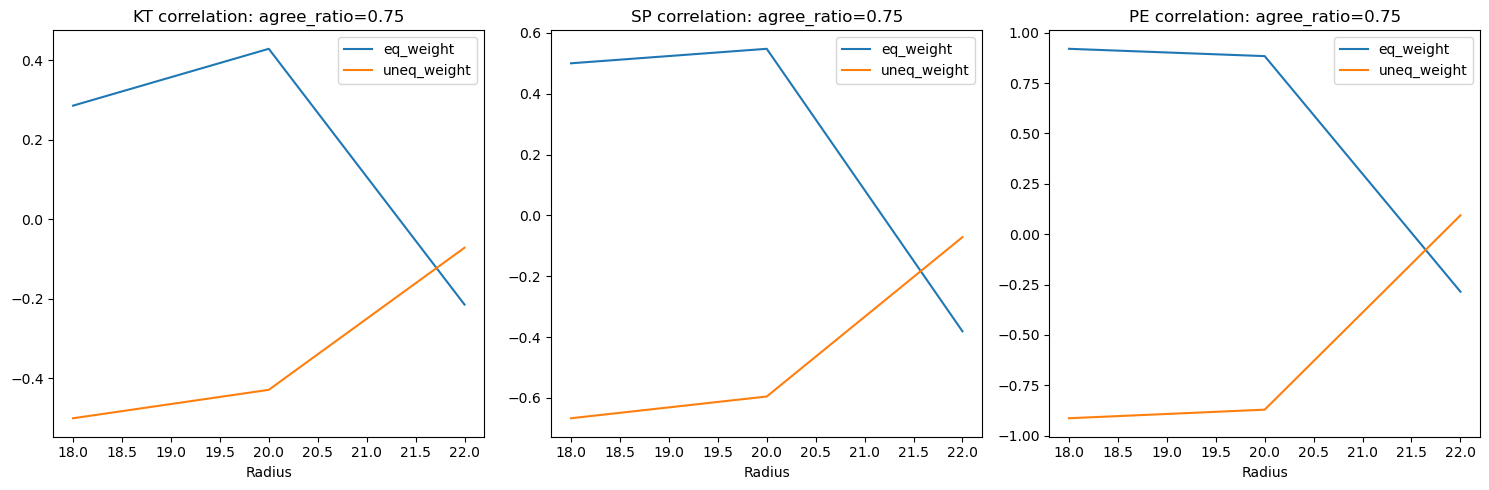

In [5]:
for agree_ratio in agree_ratios:
    kt_eq = []
    sp_eq = []
    pe_eq = []
    kt_uneq = []
    sp_uneq = []
    pe_uneq = []
    for r in radii:
        print(f"Radius: {r}, Agree ratio: {agree_ratio}")
        f1s_uneq: dict[str, float] = {}
        f1s_eq: dict[str, float] = {}
        for i, m in enumerate(methods):
            f1s_uneq[m] = uneq_f1s[r][agree_ratio][i]
            f1s_eq[m] = eq_f1s[r][agree_ratio][i]
        
        performance_scores = {target: performance_data[target]}
        SEG_scores_uneq = {target: f1s_uneq}
        SEG_scores_eq = {target: f1s_eq}

        KT_scores_eq, SP_scores_eq, PE_scores_eq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_eq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
            )
        
        kt_eq.append(KT_scores_eq[0,0,0])
        sp_eq.append(SP_scores_eq[0,0,0])
        pe_eq.append(PE_scores_eq[0,0,0])

        # correlation_df_eq = correlation_table(KT_scores_eq, SP_scores_eq, PE_scores_eq, targets=[target])
        # print("eq_weight")
        # print(correlation_df_eq)

        KT_scores_uneq, SP_scores_uneq, PE_scores_uneq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_uneq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
        )
        # correlation_df_uneq = correlation_table(KT_scores_uneq, SP_scores_uneq, PE_scores_uneq, targets=[target])
        # print("uneq_weight")
        # print(correlation_df_uneq)
        kt_uneq.append(KT_scores_uneq[0,0,0])
        sp_uneq.append(SP_scores_uneq[0,0,0])
        pe_uneq.append(PE_scores_uneq[0,0,0])
    
    f, ax = plt.subplots(1,3, figsize=(15,5))
    ax = ax.flatten()
    ax[0].plot(radii, kt_eq, label="eq_weight")
    ax[0].plot(radii, kt_uneq, label="uneq_weight")
    ax[0].set_title(f"KT correlation: agree_ratio={agree_ratio}")
    ax[0].set_xlabel("Radius")
    ax[0].legend()

    ax[1].plot(radii, sp_eq, label="eq_weight")
    ax[1].plot(radii, sp_uneq, label="uneq_weight")
    ax[1].set_title(f"SP correlation: agree_ratio={agree_ratio}")
    ax[1].set_xlabel("Radius")
    ax[1].legend()

    ax[2].plot(radii, pe_eq, label="eq_weight")
    ax[2].plot(radii, pe_uneq, label="uneq_weight")
    ax[2].set_title(f"PE correlation: agree_ratio={agree_ratio}")
    ax[2].set_xlabel("Radius")
    ax[2].legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# # Visualize weights for FlyWing
# for agree_ratio in agree_ratios:
#     n_radii = len(radii)
#     f, ax = plt.subplots(1, n_radii, figsize=(5*n_radii, 5))
#     if n_radii == 1:
#         ax = [ax]
    
#     for idx, r in enumerate(radii):
#         weights_for_radius = [float(weights[r][agree_ratio][i]) for i in range(len(methods))]
#         ax[idx].bar(methods, weights_for_radius)
#         ax[idx].set_title(f"Weights: Radius={r}, Agree_ratio={agree_ratio}")
#         ax[idx].set_ylabel("Weight")
#         ax[idx].set_ylim(0, 1)
#         ax[idx].tick_params(axis='x', rotation=45)
    
#     plt.tight_layout()
#     plt.show()

# PNAS

In [6]:
SEG_results_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/ensemble_scores/to_PNAS/SEG_results.pkl"
with open(SEG_results_path, "rb") as f:
    SEG_results = pickle.load(f)

methods = SEG_results["methods"]
agree_ratios = SEG_results["agree_ratios"]
radii = SEG_results["radii"]
weights = SEG_results["weights"]
eq_f1s = SEG_results["eq_f1s"]
uneq_f1s = SEG_results["uneq_f1s"]
target = SEG_results["target"]

Radius: 10, Agree ratio: 0.25
Radius: 12, Agree ratio: 0.25
Radius: 15, Agree ratio: 0.25


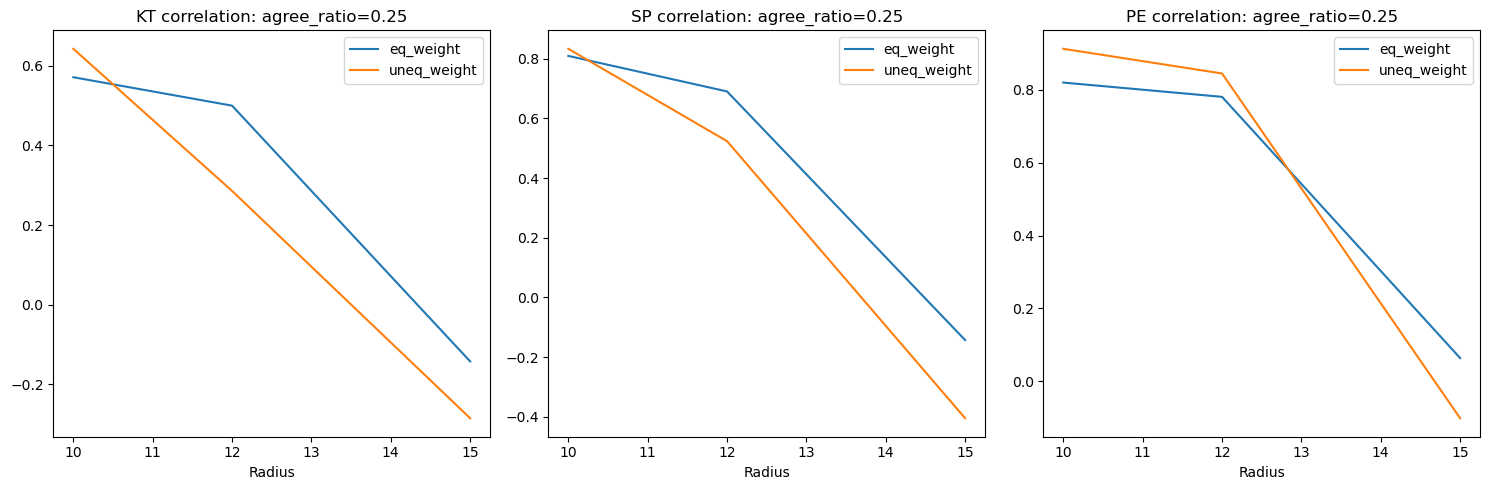

Radius: 10, Agree ratio: 0.5
Radius: 12, Agree ratio: 0.5
Radius: 15, Agree ratio: 0.5


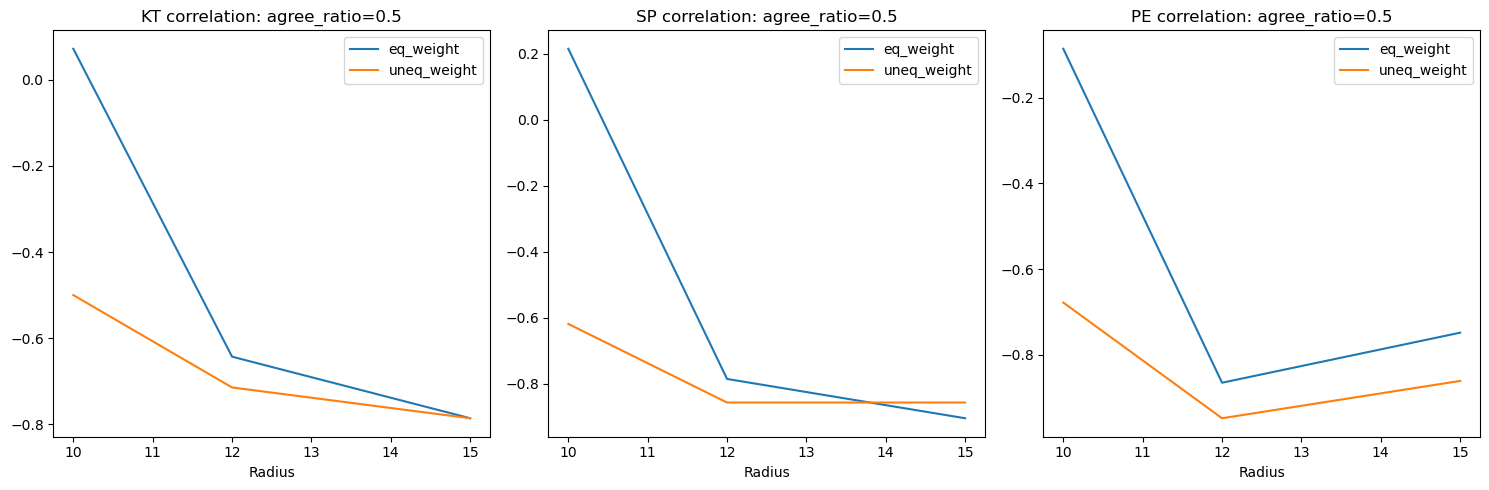

Radius: 10, Agree ratio: 0.75
Radius: 12, Agree ratio: 0.75
Radius: 15, Agree ratio: 0.75


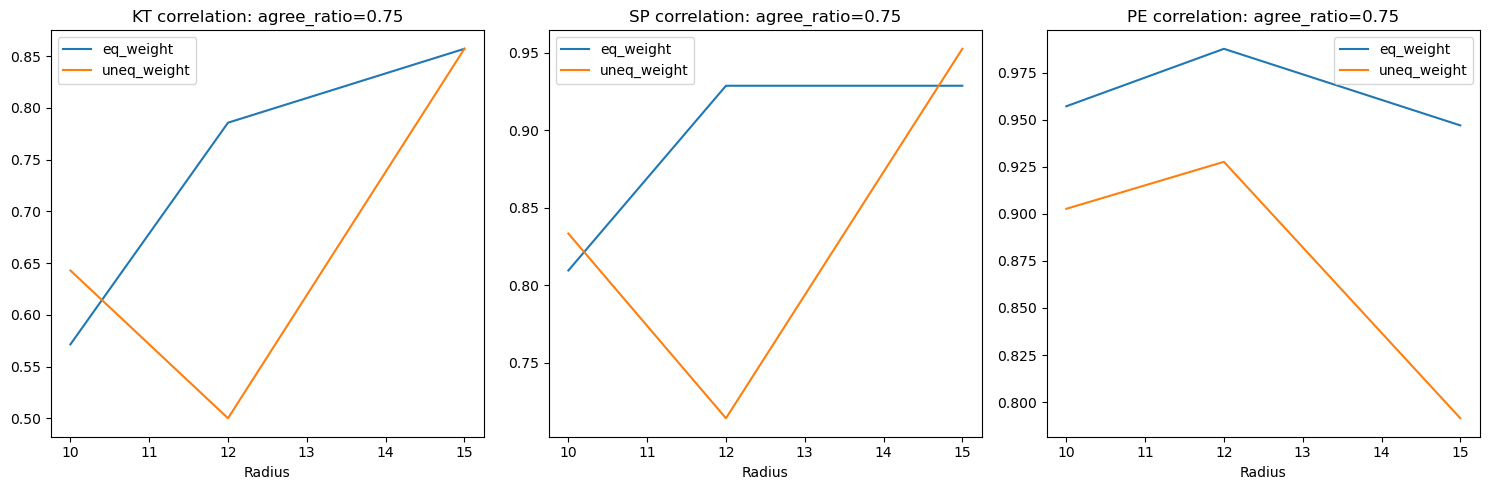

In [7]:
for agree_ratio in agree_ratios:
    kt_eq = []
    sp_eq = []
    pe_eq = []
    kt_uneq = []
    sp_uneq = []
    pe_uneq = []
    for r in radii:
        print(f"Radius: {r}, Agree ratio: {agree_ratio}")
        f1s_uneq: dict[str, float] = {}
        f1s_eq: dict[str, float] = {}
        for i, m in enumerate(methods):
            f1s_uneq[m] = uneq_f1s[r][agree_ratio][i]
            f1s_eq[m] = eq_f1s[r][agree_ratio][i]
        
        performance_scores = {target: performance_data[target]}
        SEG_scores_uneq = {target: f1s_uneq}
        SEG_scores_eq = {target: f1s_eq}

        KT_scores_eq, SP_scores_eq, PE_scores_eq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_eq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
            )
        
        kt_eq.append(KT_scores_eq[0,0,0])
        sp_eq.append(SP_scores_eq[0,0,0])
        pe_eq.append(PE_scores_eq[0,0,0])

        # correlation_df_eq = correlation_table(KT_scores_eq, SP_scores_eq, PE_scores_eq, targets=[target])
        # print("eq_weight")
        # print(correlation_df_eq)

        KT_scores_uneq, SP_scores_uneq, PE_scores_uneq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_uneq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
        )
        # correlation_df_uneq = correlation_table(KT_scores_uneq, SP_scores_uneq, PE_scores_uneq, targets=[target])
        # print("uneq_weight")
        # print(correlation_df_uneq)
        kt_uneq.append(KT_scores_uneq[0,0,0])
        sp_uneq.append(SP_scores_uneq[0,0,0])
        pe_uneq.append(PE_scores_uneq[0,0,0])
    
    f, ax = plt.subplots(1,3, figsize=(15,5))
    ax = ax.flatten()
    ax[0].plot(radii, kt_eq, label="eq_weight")
    ax[0].plot(radii, kt_uneq, label="uneq_weight")
    ax[0].set_title(f"KT correlation: agree_ratio={agree_ratio}")
    ax[0].set_xlabel("Radius")
    ax[0].legend()

    ax[1].plot(radii, sp_eq, label="eq_weight")
    ax[1].plot(radii, sp_uneq, label="uneq_weight")
    ax[1].set_title(f"SP correlation: agree_ratio={agree_ratio}")
    ax[1].set_xlabel("Radius")
    ax[1].legend()

    ax[2].plot(radii, pe_eq, label="eq_weight")
    ax[2].plot(radii, pe_uneq, label="uneq_weight")
    ax[2].set_title(f"PE correlation: agree_ratio={agree_ratio}")
    ax[2].set_xlabel("Radius")
    ax[2].legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# # Visualize weights for PNAS
# for agree_ratio in agree_ratios:
#     n_radii = len(radii)
#     f, ax = plt.subplots(1, n_radii, figsize=(5*n_radii, 5))
#     if n_radii == 1:
#         ax = [ax]
    
#     for idx, r in enumerate(radii):
#         weights_for_radius = [float(weights[r][agree_ratio][i]) for i in range(len(methods))]
#         ax[idx].bar(methods, weights_for_radius)
#         ax[idx].set_title(f"Weights: Radius={r}, Agree_ratio={agree_ratio}")
#         ax[idx].set_ylabel("Weight")
#         ax[idx].set_ylim(0, 1)
#         ax[idx].tick_params(axis='x', rotation=45)
    
#     plt.tight_layout()
#     plt.show()

# Ovules

In [8]:
SEG_results_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/ensemble_scores/to_Ovules/SEG_results.pkl"
with open(SEG_results_path, "rb") as f:
    SEG_results = pickle.load(f)

methods = SEG_results["methods"]
agree_ratios = SEG_results["agree_ratios"]
radii = SEG_results["radii"]
weights = SEG_results["weights"]
eq_f1s = SEG_results["eq_f1s"]
uneq_f1s = SEG_results["uneq_f1s"]
target = SEG_results["target"]

Radius: 12, Agree ratio: 0.25
Radius: 15, Agree ratio: 0.25
Radius: 18, Agree ratio: 0.25


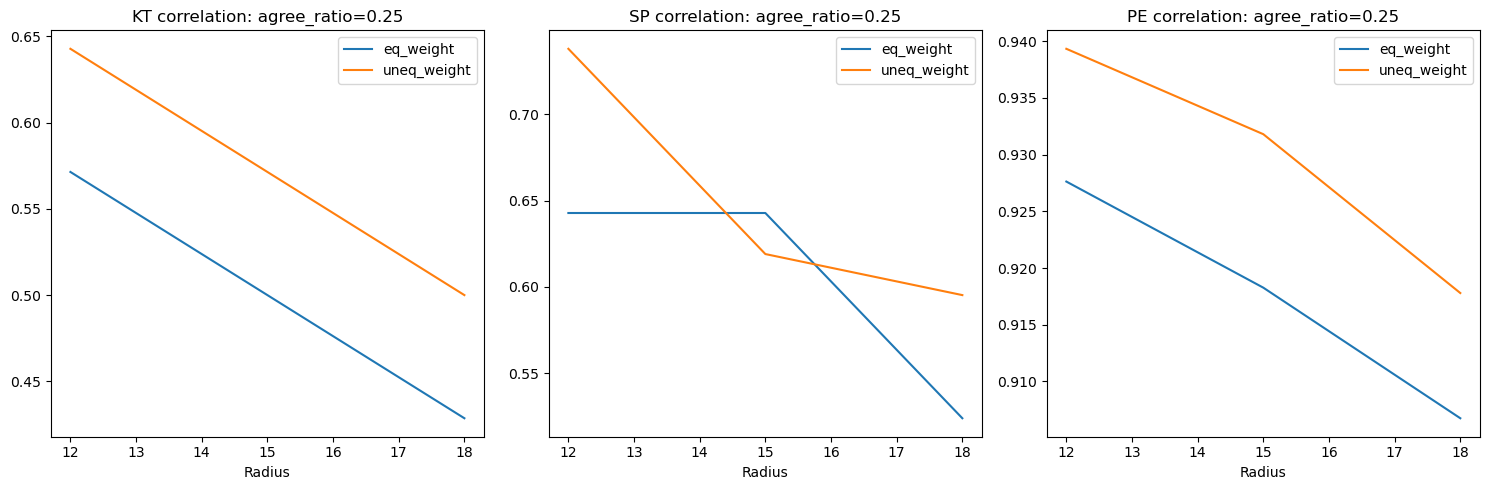

Radius: 12, Agree ratio: 0.5
Radius: 15, Agree ratio: 0.5
Radius: 18, Agree ratio: 0.5


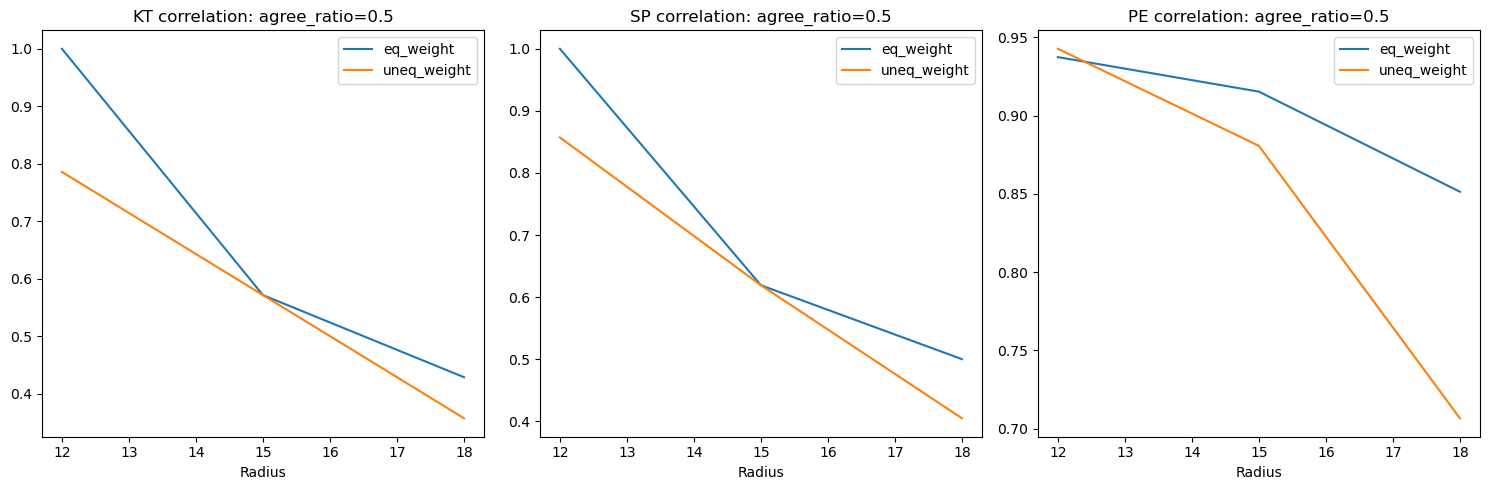

Radius: 12, Agree ratio: 0.75
Radius: 15, Agree ratio: 0.75
Radius: 18, Agree ratio: 0.75


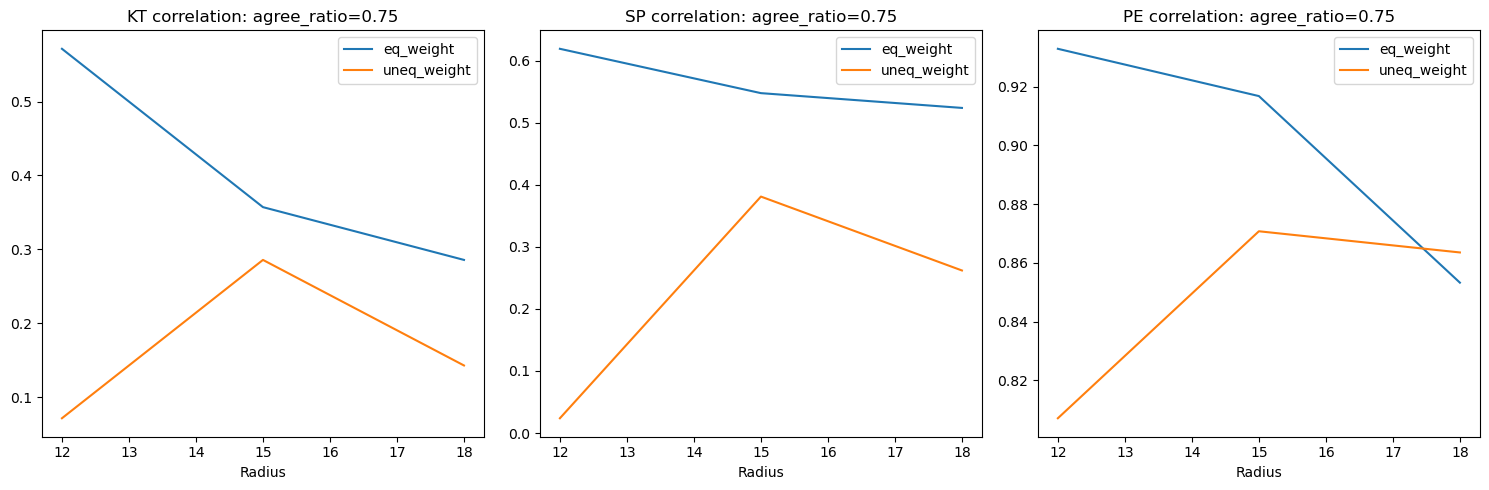

In [9]:
for agree_ratio in agree_ratios:
    kt_eq = []
    sp_eq = []
    pe_eq = []
    kt_uneq = []
    sp_uneq = []
    pe_uneq = []
    for r in radii:
        print(f"Radius: {r}, Agree ratio: {agree_ratio}")
        f1s_uneq: dict[str, float] = {}
        f1s_eq: dict[str, float] = {}
        for i, m in enumerate(methods):
            f1s_uneq[m] = uneq_f1s[r][agree_ratio][i]
            f1s_eq[m] = eq_f1s[r][agree_ratio][i]
        
        performance_scores = {target: performance_data[target]}
        SEG_scores_uneq = {target: f1s_uneq}
        SEG_scores_eq = {target: f1s_eq}

        KT_scores_eq, SP_scores_eq, PE_scores_eq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_eq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
            )
        
        kt_eq.append(KT_scores_eq[0,0,0])
        sp_eq.append(SP_scores_eq[0,0,0])
        pe_eq.append(PE_scores_eq[0,0,0])

        # correlation_df_eq = correlation_table(KT_scores_eq, SP_scores_eq, PE_scores_eq, targets=[target])
        # print("eq_weight")
        # print(correlation_df_eq)

        KT_scores_uneq, SP_scores_uneq, PE_scores_uneq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_uneq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
        )
        # correlation_df_uneq = correlation_table(KT_scores_uneq, SP_scores_uneq, PE_scores_uneq, targets=[target])
        # print("uneq_weight")
        # print(correlation_df_uneq)
        kt_uneq.append(KT_scores_uneq[0,0,0])
        sp_uneq.append(SP_scores_uneq[0,0,0])
        pe_uneq.append(PE_scores_uneq[0,0,0])
    
    f, ax = plt.subplots(1,3, figsize=(15,5))
    ax = ax.flatten()
    ax[0].plot(radii, kt_eq, label="eq_weight")
    ax[0].plot(radii, kt_uneq, label="uneq_weight")
    ax[0].set_title(f"KT correlation: agree_ratio={agree_ratio}")
    ax[0].set_xlabel("Radius")
    ax[0].legend()

    ax[1].plot(radii, sp_eq, label="eq_weight")
    ax[1].plot(radii, sp_uneq, label="uneq_weight")
    ax[1].set_title(f"SP correlation: agree_ratio={agree_ratio}")
    ax[1].set_xlabel("Radius")
    ax[1].legend()

    ax[2].plot(radii, pe_eq, label="eq_weight")
    ax[2].plot(radii, pe_uneq, label="uneq_weight")
    ax[2].set_title(f"PE correlation: agree_ratio={agree_ratio}")
    ax[2].set_xlabel("Radius")
    ax[2].legend()
    plt.tight_layout()
    plt.show()

# Average SEG scores

In [13]:
from typing import Dict
from model_ranking import avg_correlation_table

In [9]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

In [10]:
targets = ["FlyWing", "Ovules", "PNAS"]
radii = {
    "FlyWing": 20,
    "Ovules": 15,
    "PNAS": 12,
}
agree_ratio = 0.75
perf_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/transfer_performance_MAP_scores.json"
base_SEG_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/ensemble_scores"
SEG_filenames = {
    "FlyWing": "SEG_results.pkl",
    "Ovules": "SEG_results.pkl",
    "PNAS": "SEG_results.pkl",

}

In [14]:

per_target_SEG_uneq: Dict[str, Dict[str, float]] = {}
per_target_SEG_eq: Dict[str, Dict[str, float]] = {}
for target in targets:
    r = radii[target]
    print(f"Radius: {r}, Agree ratio: {agree_ratio}")

    SEG_path = Path(base_SEG_path) / f"to_{target}" / SEG_filenames[target]
    with open(SEG_path, "rb") as f:
        SEG_results = pickle.load(f)
    
    methods = SEG_results["methods"]
    eq_f1s = SEG_results["eq_f1s"]
    uneq_f1s = SEG_results["uneq_f1s"]

    f1s_uneq: Dict[str, float] = {}
    f1s_eq: Dict[str, float] = {}
    for i, m in enumerate(methods):
        f1s_uneq[m] = uneq_f1s[r][agree_ratio][i]
        f1s_eq[m] = eq_f1s[r][agree_ratio][i]
    per_target_SEG_uneq[target] = f1s_uneq
    per_target_SEG_eq[target] = f1s_eq


KT_scores_eq, SP_scores_eq, PE_scores_eq = to_target_transfer_correlations(
    targets=targets,
    transfer_metric_per_target=per_target_SEG_eq,
    performance_per_target=performance_scores,
    invert_transfer_metric=False,
    )

correlation_df_eq = correlation_table(KT_scores_eq, SP_scores_eq, PE_scores_eq, targets=targets)
print("eq_weight")
print(correlation_df_eq)
df_avg_eq = avg_correlation_table(correlation_df_eq)
print(df_avg_eq)

KT_scores_uneq, SP_scores_uneq, PE_scores_uneq = to_target_transfer_correlations(
    targets=targets,
    transfer_metric_per_target=per_target_SEG_uneq,
    performance_per_target=performance_scores,
    invert_transfer_metric=False,
)
correlation_df_uneq = correlation_table(KT_scores_uneq, SP_scores_uneq, PE_scores_uneq, targets=targets)
print("uneq_weight")
print(correlation_df_uneq)
df_avg_uneq = avg_correlation_table(correlation_df_uneq)
print(df_avg_uneq)

Radius: 20, Agree ratio: 0.75
Radius: 15, Agree ratio: 0.75
Radius: 12, Agree ratio: 0.75
eq_weight
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.43      0.2   0.55        0.16  0.88      0.0
     Ovules   0.36      0.3   0.55        0.19  0.92      0.0
     PNAS     0.79      0.0   0.93        0.00  0.99      0.0
        KT_avg    KT_std    SR_avg    SR_std  PR_avg    PR_std
Task                                                          
Mito  0.526667  0.230723  0.676667  0.219393    0.93  0.055678
uneq_weight
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing -0.43     0.16  -0.60        0.13 -0.87      0.0
     Ovules   0.29     0.39   0.38        0.37  0.87      0.0
     PNAS     0.50     0.11   0.71        0.06  0.93      0.0
      KT_avg   KT_std    SR_avg    SR_std  PR_avg   PR_std
Task                